<a href="https://colab.research.google.com/github/asdanomar15/Final_Project/blob/main/02_features_shades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Feature Exploration and Analysis



In this notebook, the features of the dataset will be explored and analyzed to better understand their characteristics and distributions.
This step helps identify patterns, relationships, and potential issues within the data.

The analysis will include examining numerical and categorical variables, understanding how they behave, and preparing them for further analysis in the following stages of the project.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:

def clean_data(df):
    df = df.drop_duplicates()

    df = df.dropna(subset=['H','S','V'])

    df['group'] = df['group'].astype('category')
    df['hex'] = df['hex'].astype('category')

    L_99 = df['L'].quantile(0.99)
    df['L'] = df['L'].apply(lambda x: min(x, L_99))

    assert df[['H','S','V','L']].isnull().sum().sum() == 0, "There are still null values in key columns!"
    assert (df['L'] > 0).all(), "Some target values are not greater than 0!"
    assert df.shape[1] == 10, "Number of columns is incorrect!"
    return df

I reused the `clean_data` function from my data cleaning notebook in this notebook.
This allowed me to apply the same consistent cleaning steps to the dataset
without rewriting the code, ensuring data quality and consistency across notebooks.

In [ ]:
df = pd.read_csv("/content/Shades_notebook2.csv", index_col=0)
df = clean_data(df)

In [ ]:
df.head()

,brand,brand_short,product,product_short,hex,H,S,V,L,group
0,Maybelline,mb,Fit Me,fmf,f3cfb3,26.0,0.26,0.95,86.0,2
1,Maybelline,mb,Fit Me,fmf,ffe3c2,32.0,0.24,1.00,92.0,2
2,Maybelline,mb,Fit Me,fmf,ffe0cd,23.0,0.20,1.00,91.0,2
3,Maybelline,mb,Fit Me,fmf,ffd3be,19.0,0.25,1.00,88.0,2
4,Maybelline,mb,Fit Me,fmf,bd9584,18.0,0.30,0.74,65.0,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 0 to 624
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   brand          609 non-null    object  
 1   brand_short    609 non-null    object  
 2   product        609 non-null    object  
 3   product_short  609 non-null    object  
 4   hex            609 non-null    category
 5   H              609 non-null    float64 
 6   S              609 non-null    float64 
 7   V              609 non-null    float64 
 8   L              609 non-null    float64 
 9   group          609 non-null    category
dtypes: category(2), float64(4), object(4)
memory usage: 65.9+ KB


In [ ]:
df.describe()

,H,S,V,L
count,609.000000,609.000000,609.000000,609.000000
mean,25.320197,0.459327,0.779442,65.637110
std,5.335852,0.154346,0.174324,17.578059
min,4.000000,0.100000,0.200000,11.000000
25%,23.000000,0.350000,0.690000,55.000000
50%,26.000000,0.440000,0.840000,70.000000
75%,29.000000,0.560000,0.910000,79.000000
max,45.000000,1.000000,1.000000,92.000000


In [ ]:
df = pd.get_dummies(df, columns=['group'])
df = pd.get_dummies(df, columns=['hex'])
#I applied one-hot encoding using `get_dummies` on the 'group' categorical column.
#This converts categorical values into binary numeric columns, allowing analysis
#and modeling algorithms to correctly interpret the categories without assuming
#any ordinal relationship between them.

In [ ]:
num_cols = ['H', 'S', 'V', 'L']

In [ ]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
#I applied standard scaling to the numerical columns ('H', 'S', 'V', 'L')
#using StandardScaler. This ensures that all numerical features have a mean
#of 0 and a standard deviation of 1, which helps improve the performance
#and stability of machine learning algorithms and ensures comparability
#between different features.

In [ ]:
# =========================
# Domain Features
# =========================

In [ ]:
df['brightness_ratio'] = df['L'] / (df['V'] + 1e-6)
#A domain-based feature called brightness_ratio was created by dividing lightness (L) by value (V).
#This helps capture how brightness relates to overall color intensity

In [ ]:
df['saturation_ratio'] = df['S'] / (df['V'] + 1e-6)
#The feature saturation_ratio was created by dividing saturation (S) by value (V).
#This represents how strong the color saturation is relative to its brightness

In [ ]:
# =========================
# Interaction Feature
# =========================

In [ ]:
df['color_intensity'] = df['S'] * df['V']
#An interaction feature called color_intensity was created by multiplying saturation (S) and value (V) to represent the overall strength and vividness of the color

In [ ]:
df['L'].skew()

np.float64(-0.7845971594538195)

Text(0.5, 1.0, 'Histogram of L before sqrt transform')

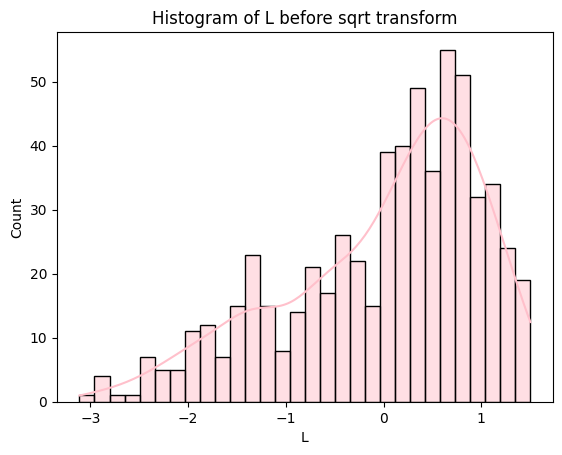

In [ ]:
sns.histplot(df['L'], bins=30, kde=True,color='pink')
plt.title("Histogram of L before sqrt transform")

In [ ]:
df['L_sqrt'] = np.sqrt(df['L'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Histogram of L after sqrt transform')

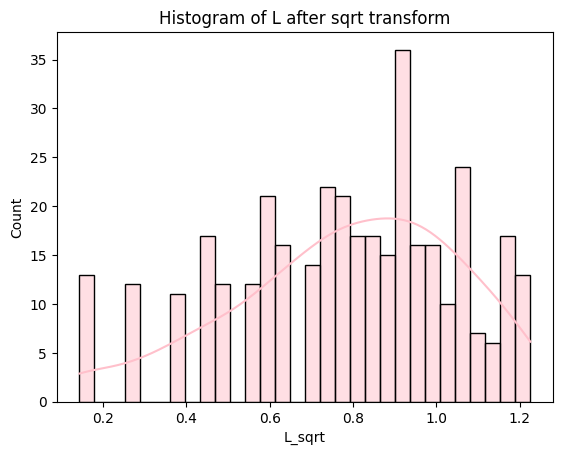

In [ ]:
sns.histplot(df['L_sqrt'], bins=30, kde=True,color='pink')
plt.title("Histogram of L after sqrt transform")

A square root transformation was applied to the L (Lightness) column to explore how a mild transformation affects the distribution. The sqrt transform reduces the spread of larger values while maintaining the general structure of the data.

In [ ]:
df['shade_level'] = pd.qcut(df['L'], q=3, labels=['Dark','Medium','Light'])

In [ ]:
df['shade_level'].value_counts()

,count
shade_level,
Dark,208
Medium,207
Light,194


The Lightness (L) column was binned into three meaningful categories:
Dark, Medium, and Light. This grouping simplifies the analysis and
helps interpret foundation shades more intuitively.

In [ ]:
cols = ['H','S','V','L','color_strength','brightness_ratio']

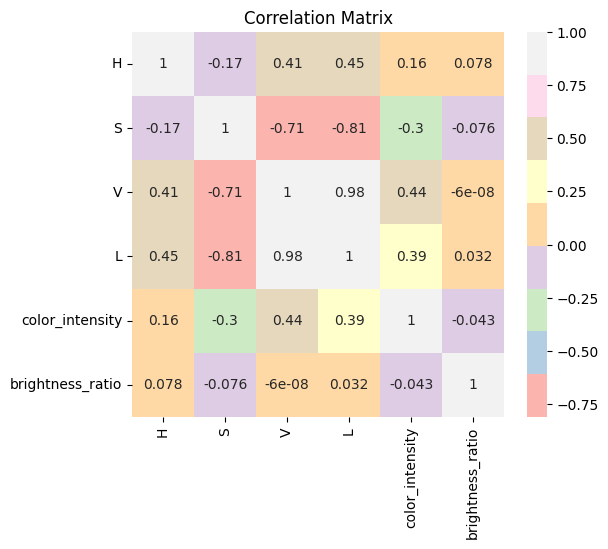

In [ ]:
cols = ['H','S','V','L','color_intensity','brightness_ratio']
corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='Pastel1')
plt.title("Correlation Matrix")
plt.show()

From the correlation heatmap, it is clear that the features V and L have a very strong positive correlation (r = 0.98), meaning they carry almost the same information. Since L is the target variable, V is considered redundant and will be removed to reduce redundancy in the dataset.

In [ ]:
df = df.drop(columns=['V'])

In [ ]:
df.head()

,brand,brand_short,product,product_short,H,S,L,group_0,group_1,group_2,...,hex_ffd8b9,hex_ffdbc2,hex_ffdcbe,hex_ffe0cd,hex_ffe3c2,brightness_ratio,saturation_ratio,color_intensity,L_sqrt,shade_level
0,Maybelline,mb,Fit Me,fmf,0.127508,-1.292488,1.159379,False,False,True,...,False,False,False,False,False,1.184001,-1.319938,-1.265608,1.076745,Light
1,Maybelline,mb,Fit Me,fmf,1.252901,-1.422174,1.500994,False,False,True,...,False,False,False,False,True,1.185374,-1.123128,-1.800843,1.225151,Light
2,Maybelline,mb,Fit Me,fmf,-0.435189,-1.681545,1.444058,False,False,True,...,False,False,False,True,False,1.140410,-1.327959,-2.129274,1.201690,Light
3,Maybelline,mb,Fit Me,fmf,-1.185451,-1.357331,1.273251,False,False,True,...,False,False,False,False,False,1.005519,-1.071920,-1.718735,1.128384,Light
4,Maybelline,mb,Fit Me,fmf,-1.373017,-1.033118,-0.036274,False,False,True,...,False,False,False,False,False,0.160194,4.562429,0.233940,NaN,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 0 to 624
Columns: 625 entries, brand to shade_level
dtypes: bool(613), category(1), float64(7), object(4)
memory usage: 422.4+ KB


In [ ]:
df.to_csv('Shades_dataset_2.csv',index=False)